# End-to-End Credit Risk Analytics & Portfolio Optimization

# Sprint 5 - Business Insights & Portfolio Optimization

## Objective

After building machine learning models, the next step is to understand **why** customers default and convert model predictions into actionable business recommendations.

This notebook focuses on:

- Feature Importance
- Risk Segmentation
- Portfolio Analysis
- Business Insights
- Final Dataset Generation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/application_train_ml.csv")

print(df.shape)

df.head()

(307511, 223)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LANDAREA_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,HAS_CAR,HAS_REALTY,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_TYPE_SUITE_Unknown,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Cleaning,ORGANIZATION_TYPE_Construction,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATION_TYPE_Emergency,ORGANIZATION_TYPE_Government,ORGANIZATION_TYPE_Hotel,ORGANIZATION_TYPE_Housing,ORGANIZATION_TYPE_Industry: type 1,ORGANIZATION_TYPE_Industry: type 10,ORGANIZATION_TYPE_Industry: type 11,ORGANIZATION_TYPE_Industry: type 12,ORGANIZATION_

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

X = X.drop("SK_ID_CURR", axis=1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

11.38710976837865


In [6]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
29,EXT_SOURCE_3,0.038489
28,EXT_SOURCE_2,0.035625
114,NAME_EDUCATION_TYPE_Higher education,0.018084
96,CODE_GENDER_M,0.015841
109,NAME_INCOME_TYPE_Pensioner,0.014394
27,EXT_SOURCE_1,0.013867
117,NAME_EDUCATION_TYPE_Secondary / secondary special,0.012645
93,HAS_CAR,0.012133
64,FLAG_DOCUMENT_3,0.011898
95,NAME_CONTRACT_TYPE_Revolving loans,0.011808


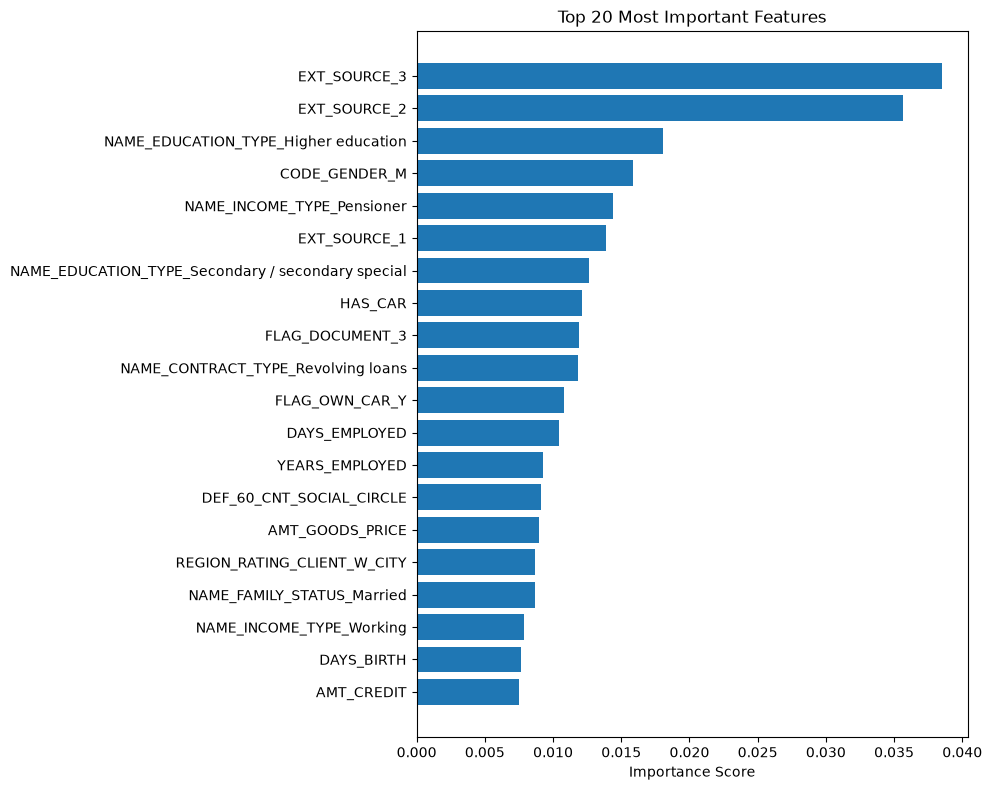

In [8]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.title("Top 20 Most Important Features")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

In [9]:
# Generate default probabilities for every customer

risk_probability = xgb_model.predict_proba(X)[:, 1]

df["RISK_SCORE"] = risk_probability

df[["TARGET", "RISK_SCORE"]].head()

/var/folders/2y/2wtbv1154yz0_9d6fhfm37lw0000gn/T/ipykernel_35353/2611928547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["RISK_SCORE"] = risk_probability


,TARGET,RISK_SCORE
0,1,0.901697
1,0,0.300679
2,0,0.333256
3,0,0.416529
4,0,0.624925


In [10]:
df["RISK_SCORE"].describe()

count    307511.000000
mean          0.400425
std           0.202702
min           0.009700
25%           0.234806
50%           0.373150
75%           0.549418
max           0.955328
Name: RISK_SCORE, dtype: float64

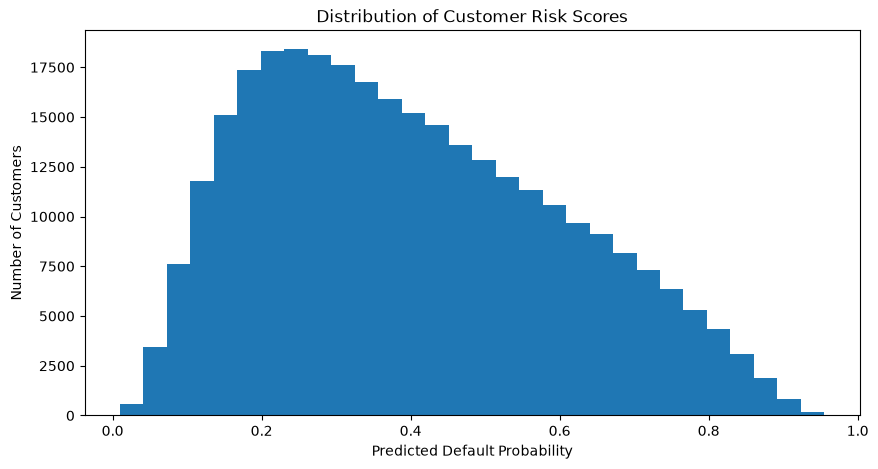

In [11]:
plt.figure(figsize=(10,5))

plt.hist(df["RISK_SCORE"], bins=30)

plt.title("Distribution of Customer Risk Scores")

plt.xlabel("Predicted Default Probability")

plt.ylabel("Number of Customers")

plt.show()

In [12]:
df.sort_values(
    by="RISK_SCORE",
    ascending=False
)[["SK_ID_CURR", "TARGET", "RISK_SCORE"]].head(10)

,SK_ID_CURR,TARGET,RISK_SCORE
260725,401727,1,0.955328
303079,451137,1,0.953270
72452,184020,0,0.952415
290481,436529,1,0.951601
291791,438040,1,0.951229
150558,274537,1,0.950989
48554,156227,1,0.949994
205531,338242,0,0.949819
286882,432274,1,0.949766
182030,310987,1,0.949611


In [13]:
def assign_risk(score):
    if score < 0.30:
        return "Low Risk"
    elif score < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

df["RISK_CATEGORY"] = df["RISK_SCORE"].apply(assign_risk)

df[["RISK_SCORE", "RISK_CATEGORY"]].head()

/var/folders/2y/2wtbv1154yz0_9d6fhfm37lw0000gn/T/ipykernel_35353/3058552098.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["RISK_CATEGORY"] = df["RISK_SCORE"].apply(assign_risk)


,RISK_SCORE,RISK_CATEGORY
0,0.901697,High Risk
1,0.300679,Medium Risk
2,0.333256,Medium Risk
3,0.416529,Medium Risk
4,0.624925,High Risk


In [14]:
df["RISK_CATEGORY"].value_counts()

RISK_CATEGORY
Medium Risk    133846
Low Risk       114579
High Risk       59086
Name: count, dtype: int64

In [15]:
risk_percent = (
    df["RISK_CATEGORY"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(risk_percent)

RISK_CATEGORY
Medium Risk    43.53
Low Risk       37.26
High Risk      19.21
Name: proportion, dtype: float64


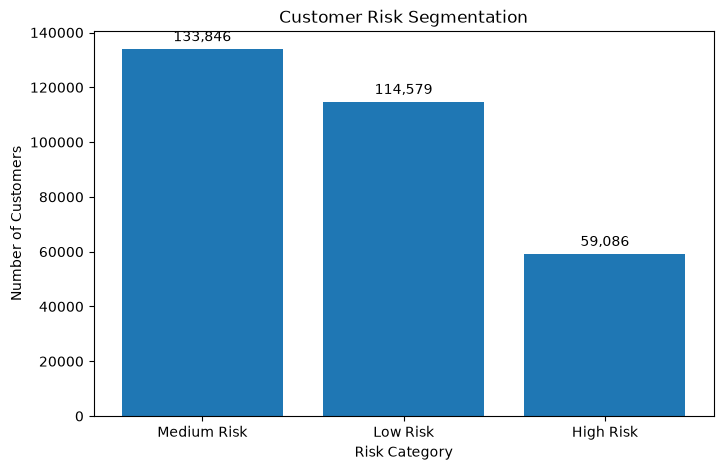

In [16]:
risk_counts = df["RISK_CATEGORY"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(risk_counts.index, risk_counts.values)

plt.title("Customer Risk Segmentation")

plt.xlabel("Risk Category")

plt.ylabel("Number of Customers")

# Add labels on top of each bar
for i, value in enumerate(risk_counts.values):
    plt.text(i, value + 3000, f"{value:,}", ha="center")

plt.show()

In [17]:
risk_summary = (
    df.groupby("RISK_CATEGORY")
      .agg(
          Customers=("TARGET", "count"),
          Defaults=("TARGET", "sum"),
          Default_Rate=("TARGET", "mean"),
          Avg_Income=("AMT_INCOME_TOTAL", "mean"),
          Avg_Credit=("AMT_CREDIT", "mean")
      )
      .reset_index()
)

risk_summary["Default_Rate"] = (
    risk_summary["Default_Rate"] * 100
).round(2)

risk_summary

,RISK_CATEGORY,Customers,Defaults,Default_Rate,Avg_Income,Avg_Credit
0,High Risk,59086,13916,23.55,157028.359150,513893.453500
1,Low Risk,114579,1637,1.43,181430.353820,647332.283913
2,Medium Risk,133846,9272,6.93,163179.555772,595254.918664


In [18]:
# Save dataset with risk scores

df.to_csv(
    "../data/processed/application_train_risk_scores.csv",
    index=False
)

print("✅ Risk scoring dataset saved successfully!")

✅ Risk scoring dataset saved successfully!


# Business Insights

## Key Findings

### 1. Customer Distribution
- Low Risk: 114,579 customers (37.26%)
- Medium Risk: 133,846 customers (43.53%)
- High Risk: 59,086 customers (19.21%)

Most customers belong to the Medium Risk category.

---

### 2. Default Rates

| Risk Category | Default Rate |
|---------------|-------------:|
| High Risk | 23.55% |
| Medium Risk | 6.93% |
| Low Risk | 1.43% |

High Risk customers are nearly four times more likely to default than Medium Risk customers.

---

### 3. Income Analysis

Average Income:

- High Risk: ₹157,028
- Medium Risk: ₹163,180
- Low Risk: ₹181,430

Lower income is associated with higher credit risk.

---

### 4. Credit Analysis

Average Credit Amount:

- High Risk: ₹513,893
- Medium Risk: ₹595,255
- Low Risk: ₹647,332

Low Risk customers generally receive larger loans because they are considered more reliable borrowers.

---

## Business Recommendations

- Automatically approve Low Risk customers.
- Conduct manual review for Medium Risk customers.
- Perform strict verification or reject High Risk applications.
- Use the predicted risk score as an additional decision-support metric for loan approval.

In [22]:
import joblib

joblib.dump(xgb_model, "../models/xgboost_credit_risk_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [23]:
feature_importance.to_csv(
    "../reports/Feature_Importance.csv",
    index=False
)

print("✅ Feature importance saved!")

✅ Feature importance saved!


In [24]:
risk_summary.to_csv(
    "../reports/Risk_Summary.csv",
    index=False
)

print("✅ Risk summary saved!")

✅ Risk summary saved!
